# Distances and nearest neighbors

## Lecture objectives

1. Introduce distance and nearest neighbor calculations

A common task is getting the distances between a geometry and a set of other geometries, or the nearest neighbor. For example, you might want to get the closest school or grocery store to a particular census tract.

First, let's load in the same dataset we used in the previous lectures.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import requests
import pygris

pantryDf = pd.read_csv('../data/Food_Resources_in_California.csv')
pantryDf = pantryDf[pantryDf.County=='Los Angeles']

# convert to a GeoDataFrame
pantrygdf = gpd.GeoDataFrame(
    pantryDf, geometry=gpd.points_from_xy(pantryDf.Longitude, pantryDf.Latitude, 
                                          crs='EPSG:4326'))

# get the census data for the City of LA
# B19019_001E is median household income
r = requests.get('https://api.census.gov/data/2019/acs/acs5?get=B19019_001E&for=tract:*&in=state:06%20county:037')
censusdata = r.json()
incomeDf = pd.DataFrame(censusdata[1:], columns=censusdata[0])
incomeDf.rename(columns={'B19019_001E':'median_HH_income'}, inplace=True)
incomeDf.median_HH_income = incomeDf.median_HH_income.astype(int)
incomeDf.loc[incomeDf.median_HH_income<0, 'median_HH_income'] = np.nan

# Add the tract boundaries. For this, we'll use the pygris package
#tracts = pygris.tracts(state='06',county='037', year=2019)
#tracts.set_index(['STATEFP','COUNTYFP','TRACTCE'], inplace=True)
#tracts.index.names=['state','county','tract']
# and join the tract boundaries to the census data
#incomeDf = tracts[['geometry']].join(incomeDf.set_index(['state','county','tract'])).reset_index()

#上ではpygrisを使っているが使えないので、ダウンロードデータを使う
tracts = gpd.read_file("/Users/Tomo/Desktop/UP213/Week4/tl_2024_06_tract.zip")  
tracts.set_index(['STATEFP','COUNTYFP','TRACTCE'], inplace=True)
tracts.index.names=['state','county','tract']
tracts = tracts[tracts.index.get_level_values('county') == '037']
incomeDf = tracts[['geometry']].join(incomeDf.set_index(['state','county','tract'])).reset_index()

For distances, the projection is important here so let's convert to State Plane. 

In [2]:
pantrygdf.to_crs('EPSG:3497', inplace=True)
incomeDf.to_crs('EPSG:3497', inplace=True)

The nearest neighbor can be found with `sjoin_nearest`. The optional argument, `distance_col`, will add a column with the distances.

In [3]:
#"distance_col"というargumentを付けることで、距離を格納する列を指定できる
incomeDf.sjoin_nearest(pantrygdf, distance_col='dist_to_pantry')

,state,county,tract,geometry,median_HH_income,index_right,Name,Street Address,City,State,Zip Code,County,Phone,Description,Resource Type,Web Link,Notes,Latitude,Longitude,dist_to_pantry
0,06,037,204920,"POLYGON ((1981264.851 557662.754, 1981265.608 ...",39904.0,406,Hollenbeck Middle School,2510 E. 6th St.,Los Angeles,CA,90023,Los Angeles,NaN,LOCAL DISTRICT EAST,Food Distribution Program,https://www.hollenbeckmiddleschool.org/,NaN,34.036520,-118.212140,1807.576286
1,06,037,205110,"POLYGON ((1979714.992 558400.997, 1979732.609 ...",47219.0,406,Hollenbeck Middle School,2510 E. 6th St.,Los Angeles,CA,90023,Los Angeles,NaN,LOCAL DISTRICT EAST,Food Distribution Program,https://www.hollenbeckmiddleschool.org/,NaN,34.036520,-118.212140,1141.377908
2,06,037,205120,"POLYGON ((1979658.894 557766.671, 1979663.062 ...",26844.0,406,Hollenbeck Middle School,2510 E. 6th St.,Los Angeles,CA,90023,Los Angeles,NaN,LOCAL DISTRICT EAST,Food Distribution Program,https://www.hollenbeckmiddleschool.org/,NaN,34.036520,-118.212140,1401.994796
3,06,037,206010,"POLYGON ((1977915.558 562949.765, 1978029.909 ...",42063.0,456,Our Lady Queen Of Angels Catholic Church,535 N. Main St.,Los Angeles,CA,90012,Los Angeles,(213) 629-3101,"This church provides clothing, emergency food ...",Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.056900,-118.239400,621.270054
4,06,037,206020,"POLYGON ((1978038.631 561508.974, 1978041.178 ...",100809.0,456,Our Lady Queen Of Angels Catholic Church,535 N. Main St.,Los Angeles,CA,90012,Los Angeles,(213) 629-3101,"This church provides clothing, emergency food ...",Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.056900,-118.239400,188.088950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2493,06,037,189600,"POLYGON ((1968907.791 567536.407, 1968911.783 ...",74760.0,409,Hope-net - Blessed Sacrament,6657 Sunset Blvd.,Los Angeles,CA,90028,Los Angeles,(323) 874-5577,The agency provides emergency food and housing...,Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.098128,-118.335028,783.342242
2494,06,037,189400,"POLYGON ((1969851.827 567838.771, 1969853.506 ...",156154.0,409,Hope-net - Blessed Sacrament,6657 Sunset Blvd.,Los Angeles,CA,90028,Los Angeles,(323) 874-5577,The agency provides emergency food and housing...,Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.098128,-118.335028,1544.535382
2495,06,037,181400,"POLYGON ((1979804.087 571014.398, 1979954.259 ...",85262.0,378,Eagle Rock High School,1750 Yosemite Drive,Los Angeles,CA,90041,Los Angeles,NaN,LOCAL DISTRICT CENTRAL,Food Distribution Program,https://erhs.la/,NaN,34.133169,-118.205530,13.894518
2496,06,037,578100,"POLYGON ((1988565.193 531860.51, 1988677.853 5...",NaN,512,St Gregory's Episcopal Church,6201 Willow St.,Long Beach,CA,90815,Los Angeles,(562) 420-1311,The church provides emergency food for people ...,Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,33.803666,-118.110506,1658.006441


Note that we only have the result for the closest part of the census tract. If we want the centroid, we can create a new GeoDataFrame and convert its polygons to centroids.

<Axes: >

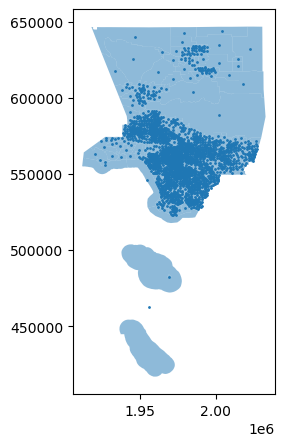

In [4]:
#上のデータは、各tractの敷地内で最もpantryに近い境界線からの距離を取っている
#tractの中心点からの距離で見たいときは、まずtractをpolygonデータからpointデータに変換する
#そこで使うのが、「.geometry.centroid」

import matplotlib.pyplot as plt

incomeDf_centroids = incomeDf.copy()
incomeDf_centroids.geometry = incomeDf.geometry.centroid

# map to show the centroids 
fig, ax=plt.subplots(figsize=(5,5)) #白紙のキャンバスを用意
incomeDf_centroids.plot(markersize=1, ax=ax) #centroidsのポイントをプロット
incomeDf.plot(ax=ax, lw=4, alpha=0.5) #tractのポリゴンもプロット

And let's do the nearest neighbor with these centroids.

In [5]:
incomeDf_centroids.sjoin_nearest(pantrygdf, distance_col='dist_to_pantry')

,state,county,tract,geometry,median_HH_income,index_right,Name,Street Address,City,State,Zip Code,County,Phone,Description,Resource Type,Web Link,Notes,Latitude,Longitude,dist_to_pantry
0,06,037,204920,POINT (1981757.545 557422.582),39904.0,481,Salvation Army Corps Community Center - East L...,140 N. Eastman Ave.,Los Angeles,CA,90063,Los Angeles,(323) 263-7577,The agency provides emergency food and utility...,Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.037121,-118.185623,2436.997864
1,06,037,205110,POINT (1980207.432 558202.676),47219.0,406,Hollenbeck Middle School,2510 E. 6th St.,Los Angeles,CA,90023,Los Angeles,NaN,LOCAL DISTRICT EAST,Food Distribution Program,https://www.hollenbeckmiddleschool.org/,NaN,34.036520,-118.212140,1347.395122
2,06,037,205120,POINT (1980437.253 557564.281),26844.0,406,Hollenbeck Middle School,2510 E. 6th St.,Los Angeles,CA,90023,Los Angeles,NaN,LOCAL DISTRICT EAST,Food Distribution Program,https://www.hollenbeckmiddleschool.org/,NaN,34.036520,-118.212140,1970.679295
3,06,037,206010,POINT (1978655.697 563121.658),42063.0,456,Our Lady Queen Of Angels Catholic Church,535 N. Main St.,Los Angeles,CA,90012,Los Angeles,(213) 629-3101,"This church provides clothing, emergency food ...",Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.056900,-118.239400,1522.567467
4,06,037,206020,POINT (1978605.162 561870.948),100809.0,456,Our Lady Queen Of Angels Catholic Church,535 N. Main St.,Los Angeles,CA,90012,Los Angeles,(213) 629-3101,"This church provides clothing, emergency food ...",Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.056900,-118.239400,710.638727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2493,06,037,189600,POINT (1969571.502 567854.802),74760.0,409,Hope-net - Blessed Sacrament,6657 Sunset Blvd.,Los Angeles,CA,90028,Los Angeles,(323) 874-5577,The agency provides emergency food and housing...,Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.098128,-118.335028,1534.728145
2494,06,037,189400,POINT (1970373.261 568830.652),156154.0,409,Hope-net - Blessed Sacrament,6657 Sunset Blvd.,Los Angeles,CA,90028,Los Angeles,(323) 874-5577,The agency provides emergency food and housing...,Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.098128,-118.335028,2751.693736
2495,06,037,181400,POINT (1980734.246 570648.859),85262.0,378,Eagle Rock High School,1750 Yosemite Drive,Los Angeles,CA,90041,Los Angeles,NaN,LOCAL DISTRICT CENTRAL,Food Distribution Program,https://erhs.la/,NaN,34.133169,-118.205530,500.727261
2496,06,037,578100,POINT (1989278.744 531341.697),NaN,512,St Gregory's Episcopal Church,6201 Willow St.,Long Beach,CA,90815,Los Angeles,(562) 420-1311,The church provides emergency food for people ...,Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,33.803666,-118.110506,2399.130763


Notice that the distances are a little larger than before.

In [6]:
incomeDf.sjoin_nearest(pantrygdf, 
        distance_col='dist_to_pantry').dist_to_pantry.mean()

1830.5281176551405

In [7]:
incomeDf_centroids.sjoin_nearest(pantrygdf, 
        distance_col='dist_to_pantry').dist_to_pantry.mean()

2686.0834012625764

What if you don't just care about the closest one, but want to get the distances from a census tract to a larger number of pantries, or even all of them? For example, some accessibility measures look at the distance to the 2nd or 3rd closest destination (e.g. a grocery store), in order to capture the number of choices that people have.

To start with, let's look at the distances to a single tract. Note that `sort_values` will sort the results, so it's easiest to see the smallest and largest distances.

In [8]:
#上では、最も近いpantryへの距離を出した。でも、すべてのpantryへの距離を知りたい、となるかもしれない
#そのやり方を、まずは1つのtractを例にしてやってみる

# as an example, take the first census tract, and get its geometry
tractgeom = incomeDf.iloc[0].geometry

# get the distances from this tract to all the food pantries
distances = pantrygdf.distance(tractgeom) #「"データ名".distance("データ名")」とすると、2つのデータ間の距離が出せる
distances.sort_values(inplace=True) #.sort_values()は「昇順（近い順）に並び替え」、inplace=True によって元の distances を上書きして並び替える
distances

406     1807.576286
481     1962.752349
436     2284.109466
345     2343.687879
430     2767.859492
           ...     
441    53910.032212
495    70665.171921
339    73720.375456
343    74760.580807
399    75603.286240
Length: 211, dtype: float64

So how do we know which one is the 3rd closest? We can use `iloc` to get the 3rd row. 

In [9]:
distances.iloc[2]

2284.1094663221224

If we want to calculate the distance to the 3rd closest pantry for each census tract, we can put this in a function.

The argument of the function will be the geometry of the tract. It will return the distance.

Once we have that function, we can use our old friend `apply` to apply it to every tract in the city of LA.

In [10]:
#3番目に近いpantryへの距離、を各tractについて出す、というfunction

def get_3rd_closest_dist(geom):
    # get distance from every pantry to a single census tract (geom)
    distances = pantrygdf.distance(geom)
    third_closest = distances.sort_values().iloc[2] #.sort_values()で昇順で並び替えた上で、そのうちの3番目をピックアップ
    return third_closest

#.apply()の中の関数が各行の.geometryの値に適用される、ということ
incomeDf['dist_third_closest'] = incomeDf.geometry.apply(get_3rd_closest_dist)

In [11]:
incomeDf

,state,county,tract,geometry,median_HH_income,dist_third_closest
0,06,037,204920,"POLYGON ((1981264.851 557662.754, 1981265.608 ...",39904.0,2284.109466
1,06,037,205110,"POLYGON ((1979714.992 558400.997, 1979732.609 ...",47219.0,2614.273867
2,06,037,205120,"POLYGON ((1979658.894 557766.671, 1979663.062 ...",26844.0,2186.356243
3,06,037,206010,"POLYGON ((1977915.558 562949.765, 1978029.909 ...",42063.0,1952.495155
4,06,037,206020,"POLYGON ((1978038.631 561508.974, 1978041.178 ...",100809.0,1936.301766
...,...,...,...,...,...,...
2493,06,037,189600,"POLYGON ((1968907.791 567536.407, 1968911.783 ...",74760.0,3280.418757
2494,06,037,189400,"POLYGON ((1969851.827 567838.771, 1969853.506 ...",156154.0,2759.730118
2495,06,037,181400,"POLYGON ((1979804.087 571014.398, 1979954.259 ...",85262.0,2996.480543
2496,06,037,578100,"POLYGON ((1988565.193 531860.51, 1988677.853 5...",NaN,2203.388831


Finally, let's plot using the `seaborn.regplot()` function that we saw before.

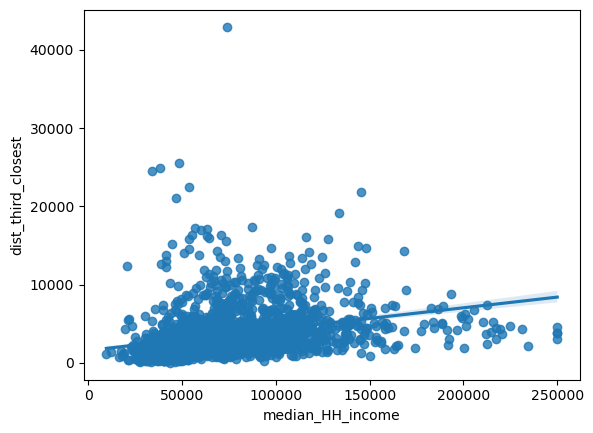

In [12]:
import seaborn as sns
ax = sns.regplot(x="median_HH_income", y="dist_third_closest", data=incomeDf)

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
  <li>Nearest neighbors, and distances are simple to calculate in geopandas.</li>
  <li>Watch your projection!</li>
</ul>
</div>